<a href="https://colab.research.google.com/github/LilianaHerrera/Maestria/blob/main/PySpark_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELDA 1 — Preparar el entorno
# ============================================================

# Google Colab no trae PySpark instalado por defecto.

!pip install pyspark -q

# Una vez instalado, importamos la clase SparkSession.
# Es el objeto que conecta nuestro código Python con el
# motor de Spark. Sin una SparkSession activa, ningún
# comando de PySpark funciona.
from pyspark.sql import SparkSession

# Confirmamos que la librería quedó disponible.
# Si esta línea no produce ningún error, la instalación fue exitosa.
print("PySpark se importó correctamente.")

PySpark se importó correctamente.


In [2]:
# ============================================================
# CELDA 2 — Encender Spark: crear la SparkSession
# ============================================================

# La SparkSession se construye paso a paso usando el patrón
# "builder" (constructor). Se encadenan varios métodos con
# punto, y al final getOrCreate() arma el objeto.
spark = (
    SparkSession.builder
    # appName: un nombre para identificar esta sesión.
    # Aparece en la interfaz de monitoreo de Spark.
    .appName("clase-bigdata")

    # master: indica DÓNDE se ejecuta Spark.
    # "local[*]" significa "en esta misma máquina, usando
    # todos los núcleos disponibles". El asterisco = todos.
    # En un clúster real aquí iría la dirección del clúster.
    .master("local[*]")

    # config: ajustes opcionales. Aquí reservamos 4 GB de
    # memoria RAM para el proceso principal de Spark.
    # Por defecto es 1 GB; subirlo ayuda con datos medianos.
    .config("spark.driver.memory", "4g")

    # getOrCreate: si ya existe una SparkSession, la reutiliza;
    # si no existe, crea una nueva. Evita errores al
    # reejecutar esta celda varias veces.
    .getOrCreate()
)

# Verificamos que la sesión quedó activa:
# spark.version devuelve el número de versión de Spark instalada.
print("Spark versión:", spark.version)

# defaultParallelism muestra cuántas tareas en paralelo
# puede ejecutar Spark a la vez (equivale al número de
# núcleos que Colab nos asignó).
print("Núcleos usados:", spark.sparkContext.defaultParallelism)

Spark versión: 4.0.3
Núcleos usados: 2


BLOQUE 4


In [3]:
# ============================================================
# CELDA 3 — El SparkContext: trabajar a nivel de RDDs
# ============================================================

# Hasta ahora tenemos "spark" (la SparkSession), que es la
# puerta de entrada al nivel de DataFrames.
# Para trabajar con RDDs (Resilient Distributed Datasets)
# necesitamos otro objeto: el SparkContext.

# El SparkContext vive DENTRO de la SparkSession y se obtiene
# con spark.sparkContext. Por convención se guarda en una
# variable corta llamada "sc".
sc = spark.sparkContext

# Resumen rápido para tener claro qué usa cada cosa:
#   - spark  -> para DataFrames (lo veremos más adelante)
#   - sc     -> para RDDs (lo que viene ahora)

# Verificamos que el SparkContext está activo.
# sc.appName devuelve el nombre que le pusimos a la sesión.
print("SparkContext activo en la aplicación:", sc.appName)

SparkContext activo en la aplicación: clase-bigdata


In [4]:
# ============================================================
# CELDA 4 — Crear el primer RDD desde una lista
# ============================================================

# Forma 1 de crear un RDD: a partir de una lista de Python
# ya existente. Sirve para experimentar con datos pequeños
# hechos a mano.

# Primero, una lista normal de Python con edades de ejemplo.
edades = [25, 38, 41, 19, 53, 28, 60]

# sc.parallelize() toma cualquier lista (o iterable) de Python
# y la convierte en un RDD: una colección distribuida y
# repartida entre los núcleos disponibles.
rdd_edades = sc.parallelize(edades)

# Importante: hasta aquí Spark NO ha procesado nada todavía.
# parallelize() es una transformación: solo deja el RDD
# "preparado". El cálculo real ocurre cuando llamemos una
# acción (lo veremos en las siguientes celdas).

# Por ahora confirmamos que el objeto se creó.
# Al imprimir un RDD, Python muestra su tipo, no su contenido,
# porque el contenido está repartido y aún no se ha traído.
print("Objeto creado:", rdd_edades)
print("Tipo de objeto:", type(rdd_edades))

Objeto creado: ParallelCollectionRDD[0] at readRDDFromFile at PythonRDD.scala:297
Tipo de objeto: <class 'pyspark.core.rdd.RDD'>


In [5]:
# ============================================================
# CELDA 5 — Crear un RDD desde un archivo de texto
# ============================================================

# Forma 2 de crear un RDD: a partir de un archivo en disco.
# Sirve para datos reales, no solo para ejemplos hechos a mano.

# Primero creamos un archivo de texto de ejemplo para tener
# algo que leer. Estas líneas simulan registros sencillos.
# (En un caso real, el archivo ya existiría: un CSV del DANE,
# unos logs, etc.)
with open("datos.csv", "w") as f:
    f.write("Bogota,2500000\n")
    f.write("Medellin,1800000\n")
    f.write("Cali,1200000\n")
    f.write("Barranquilla,900000\n")

# sc.textFile() lee un archivo de texto y crea un RDD donde
# CADA ELEMENTO es una línea del archivo.
rdd_lineas = sc.textFile("datos.csv")

# Igual que parallelize(), textFile() es perezoso: el archivo
# todavía NO se ha leído. Solo se leerá cuando llamemos una
# acción.

# Confirmamos que el objeto se creó (muestra el tipo, no el
# contenido, porque aún no se ha traído nada).
print("Objeto creado:", rdd_lineas)
print("Tipo de objeto:", type(rdd_lineas))

Objeto creado: datos.csv MapPartitionsRDD[2] at textFile at NativeMethodAccessorImpl.java:0
Tipo de objeto: <class 'pyspark.core.rdd.RDD'>


In [6]:
# ============================================================
# CELDA 6 — ¿En cuántas particiones se repartió el RDD?
# ============================================================

# Un RDD nunca se procesa como un todo: se divide en bloques
# llamados PARTICIONES. Cada partición se procesa en paralelo
# en un núcleo distinto.

# Creamos un RDD a partir de una lista de 100 números (del 0 al 99).
# range(100) genera esos números; parallelize() los convierte en RDD.
rdd = sc.parallelize(range(100))

# getNumPartitions() nos dice en cuántas particiones quedó
# repartido el RDD. Por defecto, Spark crea tantas particiones
# como núcleos haya disponibles (lo que vimos en la Celda 2).
print("Particiones por defecto:", rdd.getNumPartitions())

# Podemos cambiar el número de particiones con repartition().
# Aquí forzamos el RDD a usar 8 particiones, sin importar
# cuántos núcleos haya. Esto devuelve un RDD NUEVO
# (los RDDs son inmutables: no se modifican, se crean otros).
rdd_8 = rdd.repartition(8)

# Confirmamos el cambio en el nuevo RDD.
print("Particiones después de repartition:", rdd_8.getNumPartitions())

Particiones por defecto: 2
Particiones después de repartition: 8


In [7]:
# ============================================================
# CELDA 7 — Transformaciones: operaciones perezosas
# ============================================================

# Las TRANSFORMACIONES devuelven un nuevo RDD y son perezosas:
# no ejecutan nada todavía, solo "anotan la receta".
# Aquí están las cuatro más usadas.

# --- map(): aplica una función a CADA elemento ---
# Toma [1,2,3,4] y multiplica cada número por 2.
nums = sc.parallelize([1, 2, 3, 4])
dobles = nums.map(lambda x: x * 2)

# --- filter(): se queda solo con los que cumplen una condición ---
# De [1,2,3,4,5] conserva solo los pares.
nums2 = sc.parallelize([1, 2, 3, 4, 5])
pares = nums2.filter(lambda x: x % 2 == 0)

# --- flatMap(): aplica una función y "aplana" el resultado ---
# Cada frase se parte en palabras; flatMap junta todas
# las palabras en una sola lista (no una lista de listas).
lineas = sc.parallelize(["hola mundo", "adios mundo"])
palabras = lineas.flatMap(lambda s: s.split())

# --- reduceByKey(): agrega por clave en RDDs de pares (clave, valor) ---
# Suma los valores que comparten la misma clave.
pares_kv = sc.parallelize([("a", 1), ("b", 1), ("a", 1)])
conteos = pares_kv.reduceByKey(lambda x, y: x + y)

# Hasta aquí NADA se ha ejecutado: las cuatro variables
# (dobles, pares, palabras, conteos) son RDDs con la receta
# anotada, pero sin resultados calculados todavía.
print("Cuatro transformaciones definidas (aún no ejecutadas).")
print("dobles  ->", dobles)
print("pares   ->", pares)
print("palabras->", palabras)
print("conteos ->", conteos)

Cuatro transformaciones definidas (aún no ejecutadas).
dobles  -> PythonRDD[17] at RDD at PythonRDD.scala:56
pares   -> PythonRDD[18] at RDD at PythonRDD.scala:56
palabras-> PythonRDD[19] at RDD at PythonRDD.scala:56
conteos -> PythonRDD[20] at RDD at PythonRDD.scala:56


In [8]:
# ============================================================
# CELDA 8 — Acciones: operaciones que SÍ ejecutan
# ============================================================

# Las ACCIONES disparan el cálculo: toman la receta anotada
# por las transformaciones y la ejecutan, devolviendo un
# resultado concreto al programa Python.
# Aquí aplicamos las cuatro acciones más usadas sobre el RDD
# de edades que creamos en la Celda 4 (rdd_edades).

# --- collect(): trae TODOS los elementos al programa ---
# Útil solo con RDDs pequeños: si el RDD es grande, puede
# agotar la memoria del programa. Aquí es seguro: son 7 datos.
print("collect():", rdd_edades.collect())

# --- count(): devuelve el número total de elementos ---
# Es la acción más segura: funciona con RDDs de cualquier
# tamaño porque solo devuelve un número entero.
print("count():", rdd_edades.count())

# --- take(3): trae los primeros 3 elementos ---
# Sirve para inspeccionar un RDD sin traerlo completo.
# Equivale al head() de R o al .head(n) de pandas.
print("take(3):", rdd_edades.take(3))

# --- reduce(): combina todos los elementos en uno solo ---
# Recibe una función que toma dos valores y devuelve uno.
# Aquí suma todas las edades: 25+38+41+19+53+28+60 = 264
print("reduce() suma de edades:", rdd_edades.reduce(lambda x, y: x + y))

collect(): [25, 38, 41, 19, 53, 28, 60]
count(): 7
take(3): [25, 38, 41]
reduce() suma de edades: 264


In [15]:
# ============================================================
# CELDA 9 — EJERCICIO 4: conteo de palabras con RDDs
# ============================================================

# Este código procesa una lista de frases y cuenta cuántas
# veces aparece cada palabra. Antes de ejecutar cada acción,
# trate de PREDECIR qué va a imprimir. Luego ejecute y compare.

# --- Preparación: una lista de frases dentro de un RDD ---
frases = sc.parallelize([
    "el dato es poder",
    "el dato sin contexto es ruido",
    "el contexto es estadistica"
])

# flatMap parte cada frase en palabras y aplana el resultado:
# queda un RDD con TODAS las palabras sueltas, una por elemento.
palabras = frases.flatMap(lambda s: s.split())

# map convierte cada palabra en un par (palabra, 1).
# Este formato (clave, valor) es el que necesita reduceByKey.
pares = palabras.map(lambda w: (w, 1))

# reduceByKey suma los "1" que comparten la misma palabra:
# el resultado es cada palabra con su conteo total.
conteos = pares.reduceByKey(lambda x, y: x + y)


# ------------------------------------------------------------
# PREGUNTAS: prediga el resultado, luego descomente y ejecute.
# Las tres líneas son ACCIONES: las tres disparan ejecución.
# ------------------------------------------------------------

# A) ¿Qué imprime esta línea?
print("A)", frases.count())

# B) ¿Qué imprime esta línea?
print("B)", palabras.take(5))

# C) ¿Qué imprime esta línea?
print("C)", conteos.collect())

A) 3
B) ['el', 'dato', 'es', 'poder', 'el']
C) [('es', 3), ('poder', 1), ('contexto', 2), ('estadistica', 1), ('el', 3), ('dato', 2), ('sin', 1), ('ruido', 1)]


BLOQUE 5

In [10]:
# ============================================================
# CELDA 10 — Leer un CSV como Spark DataFrame
# ============================================================

# Primero creamos un archivo CSV de ejemplo para tener algo
# que leer. Simula datos de una encuesta de hogares: cada fila
# es una persona, con su departamento, edad e ingreso mensual.
# (En un caso real, el archivo ya existiría: un CSV del DANE,
# de la GEIH —Gran Encuesta Integrada de Hogares—, etc.)
with open("geih_2024.csv", "w") as f:
    f.write("depto,edad,ingreso\n")          # primera fila: nombres de columna
    f.write("Bogota,34,2500000\n")
    f.write("Bogota,28,1800000\n")
    f.write("Antioquia,45,2200000\n")
    f.write("Antioquia,52,3100000\n")
    f.write("Valle,19,900000\n")
    f.write("Valle,38,1600000\n")
    f.write("Atlantico,41,1400000\n")
    f.write("Atlantico,25,1100000\n")

# spark.read lee el archivo y lo convierte en un Spark DataFrame.
df = (
    spark.read
    # header=True: la primera fila contiene los nombres de
    # las columnas (depto, edad, ingreso), no datos.
    .option("header", True)

    # inferSchema=True: Spark deduce el tipo de cada columna.
    # Sin esta opción, edad e ingreso se leerían como texto
    # en lugar de números.
    .option("inferSchema", True)

    # .csv(...) indica la ruta del archivo a leer.
    .csv("geih_2024.csv")
)

# printSchema() muestra la estructura: nombre y tipo de cada
# columna. Así confirmamos que inferSchema funcionó.
df.printSchema()

# show(5) imprime las primeras 5 filas. Es una ACCIÓN:
# aquí sí se ejecuta la lectura del archivo.
df.show(5)

# conocer el tamaño del dataset
# df.count() devuelve el número de filas (es una acción).
print("Número de filas:", df.count())
# len(df.columns) devuelve el número de columnas.
# df.columns es la lista de nombres; len() la cuenta.
print("Número de columnas:", len(df.columns))

root
 |-- depto: string (nullable = true)
 |-- edad: integer (nullable = true)
 |-- ingreso: integer (nullable = true)

+---------+----+-------+
|    depto|edad|ingreso|
+---------+----+-------+
|   Bogota|  34|2500000|
|   Bogota|  28|1800000|
|Antioquia|  45|2200000|
|Antioquia|  52|3100000|
|    Valle|  19| 900000|
+---------+----+-------+
only showing top 5 rows
Número de filas: 8
Número de columnas: 3


In [11]:
# ============================================================
# CELDA 11 — Operaciones esenciales sobre un DataFrame
# ============================================================

# Tres operaciones cubren la mayoría del trabajo diario:
# elegir columnas, filtrar filas y crear columnas nuevas.
# La sintaxis es muy parecida a pandas y a dplyr de R.

# --- select(): elegir columnas ---
# Se queda solo con las columnas "depto" y "edad".
# Equivale a   df[['depto','edad']]   en pandas.
df.select("depto", "edad").show()

# --- filter(): filtrar filas ---
# Conserva solo las filas donde la edad es mayor a 30.
# Equivale a   df[df.edad > 30]   en pandas.
df.filter(df.edad > 30).show()

# --- withColumn(): crear una columna nueva ---
# Agrega la columna "adulto", que es True si edad >= 18.
# Equivale a   df['adulto'] = df.edad >= 18   en pandas.
# withColumn devuelve un DataFrame NUEVO (no modifica df).
df.withColumn("adulto", df.edad >= 18).show()

+---------+----+
|    depto|edad|
+---------+----+
|   Bogota|  34|
|   Bogota|  28|
|Antioquia|  45|
|Antioquia|  52|
|    Valle|  19|
|    Valle|  38|
|Atlantico|  41|
|Atlantico|  25|
+---------+----+

+---------+----+-------+
|    depto|edad|ingreso|
+---------+----+-------+
|   Bogota|  34|2500000|
|Antioquia|  45|2200000|
|Antioquia|  52|3100000|
|    Valle|  38|1600000|
|Atlantico|  41|1400000|
+---------+----+-------+

+---------+----+-------+------+
|    depto|edad|ingreso|adulto|
+---------+----+-------+------+
|   Bogota|  34|2500000|  true|
|   Bogota|  28|1800000|  true|
|Antioquia|  45|2200000|  true|
|Antioquia|  52|3100000|  true|
|    Valle|  19| 900000|  true|
|    Valle|  38|1600000|  true|
|Atlantico|  41|1400000|  true|
|Atlantico|  25|1100000|  true|
+---------+----+-------+------+



In [12]:
# ============================================================
# CELDA 12 — Resumir un dataset: groupBy + agg
# ============================================================

# Para calcular medidas resumen por grupo se usa groupBy()
# seguido de agg(). Es el equivalente al .groupby().agg() de
# pandas o al aggregate() / summarize() de R, pero el cálculo
# se hace en paralelo entre los núcleos.

# Importamos el módulo de funciones de PySpark.
# Por convención se le pone el alias "F".
# Trae funciones como F.mean, F.count, F.stddev, etc.
from pyspark.sql import functions as F

# --- Agregación simple: promedio de ingreso por departamento ---
# groupBy("depto") agrupa las filas por departamento.
# agg(...) calcula la media del ingreso en cada grupo.
# alias("ingreso_prom") le pone nombre a la columna resultante.
promedios = (
    df
    .groupBy("depto")
    .agg(F.mean("ingreso").alias("ingreso_prom"))
)
promedios.show()

# --- Varias agregaciones a la vez sobre el mismo grupo ---
# En un solo agg() se pueden pedir varias estadísticas:
#   F.count("*")   -> número de registros del grupo
#   F.mean(...)    -> media
#   F.stddev(...)  -> desviación estándar
#   F.expr(...)    -> permite expresiones, aquí la mediana (percentil 0.5)
resumen = (
    df
    .groupBy("depto")
    .agg(
        F.count("*").alias("n"),
        F.mean("ingreso").alias("media"),
        F.stddev("ingreso").alias("sd"),
        F.expr("percentile(ingreso, 0.5)").alias("mediana")
    )
)

# show() es una acción: aquí se ejecuta todo el cálculo.
resumen.show()

+---------+------------+
|    depto|ingreso_prom|
+---------+------------+
|Antioquia|   2650000.0|
|   Bogota|   2150000.0|
|Atlantico|   1250000.0|
|    Valle|   1250000.0|
+---------+------------+

+---------+---+---------+------------------+---------+
|    depto|  n|    media|                sd|  mediana|
+---------+---+---------+------------------+---------+
|Antioquia|  2|2650000.0| 636396.1030678927|2650000.0|
|   Bogota|  2|2150000.0|494974.74683058326|2150000.0|
|Atlantico|  2|1250000.0|212132.03435596425|1250000.0|
|    Valle|  2|1250000.0|494974.74683058326|1250000.0|
+---------+---+---------+------------------+---------+



Tipo de objeto: <class 'pandas.core.frame.DataFrame'>
       depto      media
0  Antioquia  2650000.0
1     Bogota  2150000.0
2  Atlantico  1250000.0
3      Valle  1250000.0


<Axes: xlabel='depto'>

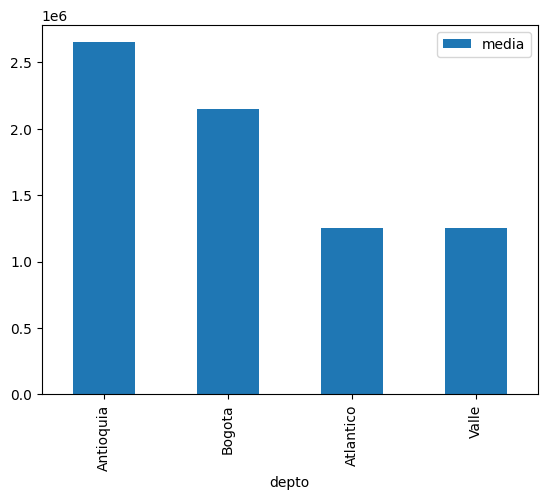

In [13]:
# ============================================================
# CELDA 13 — De Spark a pandas: procesar, traer, visualizar
# ============================================================

# Spark no es la mejor herramienta para todo. Para graficar
# o ajustar modelos, conviene REDUCIR el dataset masivo a un
# resumen pequeño usando Spark, y luego TRAER ese resumen a
# pandas. Este es el patrón típico en tres pasos.

# --- Paso 1: procesar lo masivo en Spark ---
# Calculamos el ingreso promedio por departamento.
# Sigue siendo un Spark DataFrame: distribuido y perezoso.
resumen_spark = (
    df
    .groupBy("depto")
    .agg(F.mean("ingreso").alias("media"))
)

# --- Paso 2: traer el resumen a pandas ---
# toPandas() convierte el Spark DataFrame en un DataFrame
# de pandas normal. ATENCIÓN: trae TODO a la memoria de
# esta máquina. Solo es seguro porque el resumen es pequeño
# (un puñado de filas). Nunca usar toPandas() sobre un
# dataset grande sin agregar o filtrar antes.
resumen_pd = resumen_spark.toPandas()

# Ahora resumen_pd es un DataFrame de pandas: se puede usar
# con todo el ecosistema habitual (matplotlib, seaborn,
# scikit-learn, etc.).
print("Tipo de objeto:", type(resumen_pd))
print(resumen_pd)

# --- Paso 3: visualizar o modelar con pandas ---
# Con el resumen ya en pandas, se grafica como siempre.
resumen_pd.plot(kind="bar", x="depto", y="media")

In [17]:
# ============================================================
# CELDA 14 — EJERCICIO 5: traducir de pandas a PySpark
# ============================================================

# Para cada operación escrita en pandas, escriba debajo la
# versión equivalente en PySpark, usando el DataFrame "df".
# Primero intente resolverlo; luego ejecute para comprobar.

# Recuerde que para la media necesita el módulo de funciones:
from pyspark.sql import functions as F


# ------------------------------------------------------------
# A) filtro de adultos
#    pandas:  df[df.edad >= 18]
# ------------------------------------------------------------
# Escriba aquí la versión en PySpark y descoméntela:
df.filter(df.edad >= 18).show()


# ------------------------------------------------------------
# B) selección de columnas
#    pandas:  df[['nombre', 'depto']]
#    (en nuestro CSV las columnas son: depto, edad, ingreso)
# ------------------------------------------------------------
# Escriba aquí la versión en PySpark y descoméntela:
df.select("depto", "edad").show()


# ------------------------------------------------------------
# C) conteo por grupo
# pandas:  df.groupby('depto').size()
# ------------------------------------------------------------
# Escriba aquí la versión en PySpark y descoméntela:
df.groupBy("depto").count().show()


# ------------------------------------------------------------
# D) media por grupo
# pandas:  df.groupby('depto')['ingreso'].mean()
promedios = (
    df
    .groupBy("depto")
    .agg(F.mean("ingreso").alias("ingreso_prom"))
)
promedios.show()

# ----------------------------------------------------------

+---------+----+-------+
|    depto|edad|ingreso|
+---------+----+-------+
|   Bogota|  34|2500000|
|   Bogota|  28|1800000|
|Antioquia|  45|2200000|
|Antioquia|  52|3100000|
|    Valle|  19| 900000|
|    Valle|  38|1600000|
|Atlantico|  41|1400000|
|Atlantico|  25|1100000|
+---------+----+-------+

+---------+----+
|    depto|edad|
+---------+----+
|   Bogota|  34|
|   Bogota|  28|
|Antioquia|  45|
|Antioquia|  52|
|    Valle|  19|
|    Valle|  38|
|Atlantico|  41|
|Atlantico|  25|
+---------+----+

+---------+-----+
|    depto|count|
+---------+-----+
|Antioquia|    2|
|   Bogota|    2|
|Atlantico|    2|
|    Valle|    2|
+---------+-----+

+---------+------------+
|    depto|ingreso_prom|
+---------+------------+
|Antioquia|   2650000.0|
|   Bogota|   2150000.0|
|Atlantico|   1250000.0|
|    Valle|   1250000.0|
+---------+------------+

